# Compare Runs

Load every `summary.json` under `results/` and visualize entity-level F1, per-class F1, precision/recall, and training time across runs.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_DIR = REPO_ROOT / 'results'
RESULTS_DIR

PosixPath('/Users/dayanbattulga/Desktop/personal-code/misc/dunedain_ner/results')

In [2]:
summary_paths = sorted(RESULTS_DIR.glob('*/summary.json'))
print(f'Found {len(summary_paths)} summary.json files:')
for p in summary_paths:
    print(' -', p.relative_to(REPO_ROOT))

Found 4 summary.json files:
 - results/phase_b_teacher_seed5768/summary.json
 - results/phase_b_teacher_seed78516/summary.json
 - results/phase_b_teacher_seed88/summary.json
 - results/smoke_test_seed88/summary.json


In [3]:
def load_summary(path: Path) -> dict:
    with open(path) as f:
        data = json.load(f)
    cfg = data.get('config', {})
    val = data.get('val_metrics', {}) or {}
    test = data.get('test_metrics', {}) or {}
    val_per = val.get('entity_per_class', {})
    test_per = test.get('entity_per_class', {})
    return {
        'run_id': data.get('run_id', path.parent.name),
        'model': cfg.get('model_name'),
        'seed': cfg.get('resolved_seed', (cfg.get('seeds') or [None])[0]),
        'use_crf': cfg.get('use_crf', False),
        'use_distillation': cfg.get('use_distillation', False),
        'num_epochs': cfg.get('num_epochs'),
        'lr': cfg.get('learning_rate'),
        'param_count': data.get('param_count'),
        'train_time_min': data.get('train_time_min'),
        'best_val_entity_f1': data.get('best_validation_entity_f1'),
        'val_token_f1': val.get('token_weighted_f1'),
        'val_entity_f1': val.get('entity_overall_f1'),
        'val_entity_precision': val.get('entity_overall_precision'),
        'val_entity_recall': val.get('entity_overall_recall'),
        'val_per_f1': val_per.get('PER'),
        'val_loc_f1': val_per.get('LOC'),
        'val_org_f1': val_per.get('ORG'),
        'test_token_f1': test.get('token_weighted_f1'),
        'test_entity_f1': test.get('entity_overall_f1'),
        'test_entity_precision': test.get('entity_overall_precision'),
        'test_entity_recall': test.get('entity_overall_recall'),
        'test_per_f1': test_per.get('PER'),
        'test_loc_f1': test_per.get('LOC'),
        'test_org_f1': test_per.get('ORG'),
    }

rows = [load_summary(p) for p in summary_paths]
df = pd.DataFrame(rows).sort_values('run_id').reset_index(drop=True)
df

,run_id,model,seed,use_crf,use_distillation,num_epochs,lr,param_count,train_time_min,best_val_entity_f1,...,val_per_f1,val_loc_f1,val_org_f1,test_token_f1,test_entity_f1,test_entity_precision,test_entity_recall,test_per_f1,test_loc_f1,test_org_f1
0,phase_b_teacher_seed5768,roberta-large,5768,False,False,30,0.00001,354317319,47.715483,0.917842,...,0.967509,0.930591,0.883117,0.985226,0.850991,0.835165,0.867428,0.956217,0.844371,0.802092
1,phase_b_teacher_seed78516,roberta-large,78516,False,False,30,0.00001,354317319,33.872922,0.912863,...,0.970803,0.941176,0.862963,0.985004,0.847530,0.822994,0.873573,0.956063,0.854400,0.790295
2,phase_b_teacher_seed88,roberta-large,88,False,False,30,0.00001,354317319,40.889261,0.914754,...,0.963768,0.938144,0.874101,0.985251,0.846832,0.811093,0.885865,0.943060,0.862682,0.793677
3,smoke_test_seed88,distilbert-base-cased,88,False,False,1,0.00001,65196295,0.538876,0.407106,...,0.250765,0.456044,0.457576,0.951351,0.411483,0.376917,0.453029,0.225191,0.458844,0.461430


## Overall entity F1 (validation vs test)

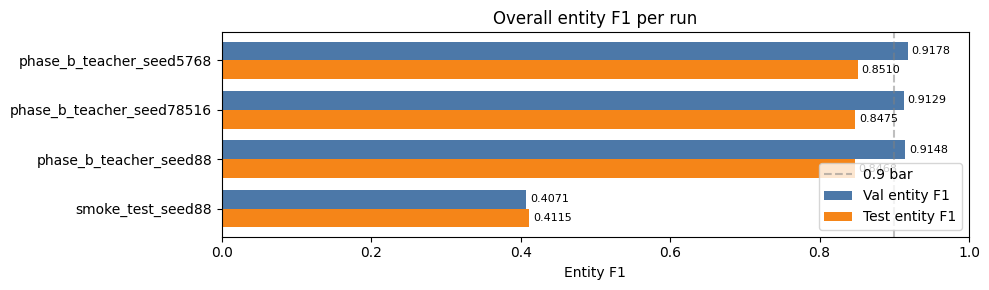

In [4]:
fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(df) + 1)))
y = np.arange(len(df))
h = 0.38
ax.barh(y - h/2, df['val_entity_f1'].fillna(0), h, label='Val entity F1', color='#4C78A8')
ax.barh(y + h/2, df['test_entity_f1'].fillna(0), h, label='Test entity F1', color='#F58518')
ax.set_yticks(y)
ax.set_yticklabels(df['run_id'])
ax.set_xlabel('Entity F1')
ax.set_xlim(0, 1)
ax.axvline(0.9, linestyle='--', color='gray', alpha=0.5, label='0.9 bar')
ax.legend(loc='lower right')
ax.invert_yaxis()
ax.set_title('Overall entity F1 per run')
for i, (v, t) in enumerate(zip(df['val_entity_f1'], df['test_entity_f1'])):
    if pd.notna(v):
        ax.text(v + 0.005, i - h/2, f'{v:.4f}', va='center', fontsize=8)
    if pd.notna(t):
        ax.text(t + 0.005, i + h/2, f'{t:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Per-class entity F1 on test set

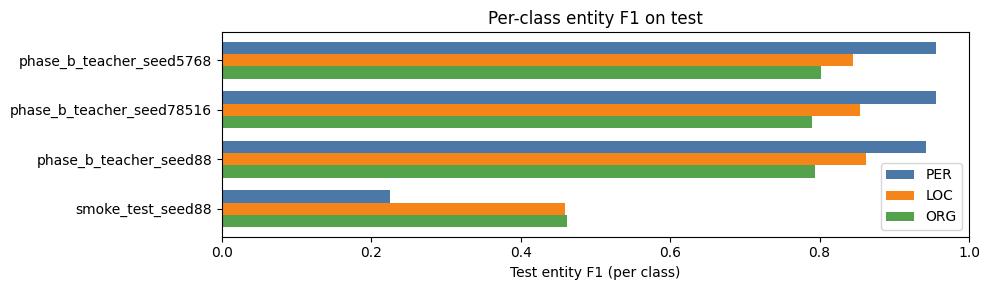

In [5]:
classes = ['PER', 'LOC', 'ORG']
cols = ['test_per_f1', 'test_loc_f1', 'test_org_f1']
fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(df) + 1)))
y = np.arange(len(df))
h = 0.25
colors = ['#4C78A8', '#F58518', '#54A24B']
for i, (c, col, color) in enumerate(zip(classes, cols, colors)):
    offset = (i - 1) * h
    ax.barh(y + offset, df[col].fillna(0), h, label=c, color=color)
ax.set_yticks(y)
ax.set_yticklabels(df['run_id'])
ax.set_xlabel('Test entity F1 (per class)')
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.set_title('Per-class entity F1 on test')
plt.tight_layout()
plt.show()

## Precision / Recall / F1 on test set

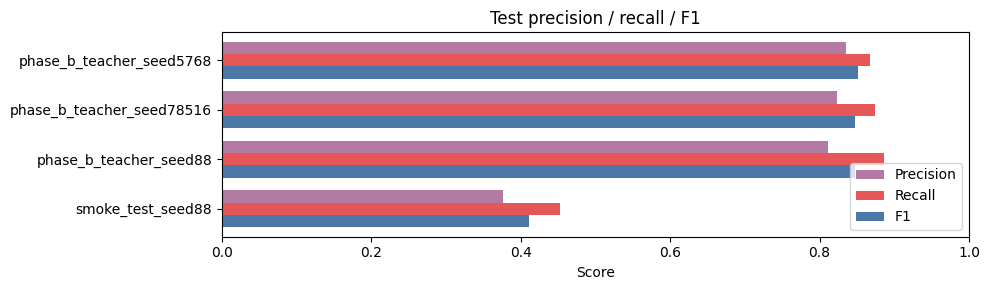

In [6]:
fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(df) + 1)))
y = np.arange(len(df))
h = 0.25
ax.barh(y - h, df['test_entity_precision'].fillna(0), h, label='Precision', color='#B279A2')
ax.barh(y,      df['test_entity_recall'].fillna(0),    h, label='Recall',    color='#E45756')
ax.barh(y + h,  df['test_entity_f1'].fillna(0),        h, label='F1',        color='#4C78A8')
ax.set_yticks(y)
ax.set_yticklabels(df['run_id'])
ax.set_xlabel('Score')
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.set_title('Test precision / recall / F1')
plt.tight_layout()
plt.show()

## Train time vs test entity F1

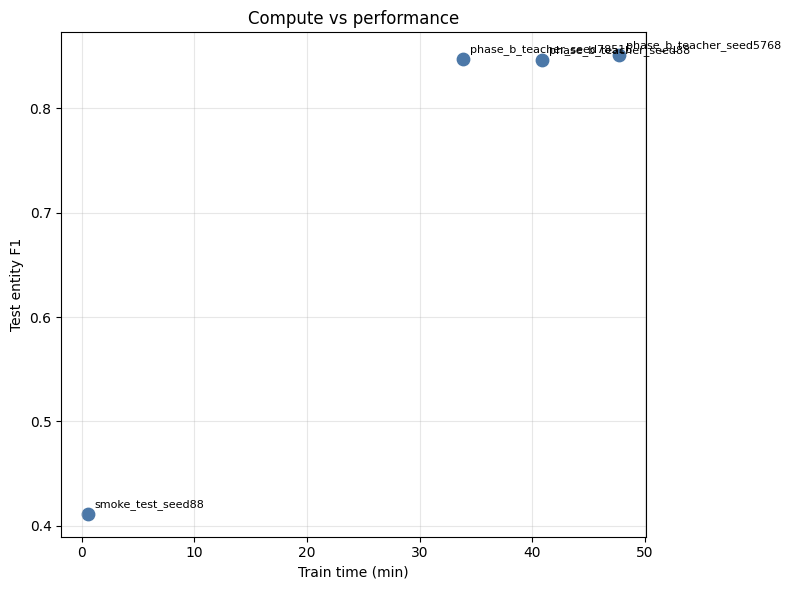

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sub = df.dropna(subset=['train_time_min', 'test_entity_f1'])
ax.scatter(sub['train_time_min'], sub['test_entity_f1'], s=80, color='#4C78A8')
for _, row in sub.iterrows():
    ax.annotate(row['run_id'], (row['train_time_min'], row['test_entity_f1']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Train time (min)')
ax.set_ylabel('Test entity F1')
ax.set_title('Compute vs performance')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Seed aggregation (mean ± std by model / variant)

In [8]:
def variant(row):
    tag = row['model'] or 'unknown'
    if row['use_crf']:
        tag += '+crf'
    if row['use_distillation']:
        tag += '+distill'
    return tag

df['variant'] = df.apply(variant, axis=1)
# strip seed suffix so multi-seed runs collapse
df['run_group'] = df['run_id'].str.replace(r'_seed\d+$', '', regex=True)

agg_cols = ['test_entity_f1', 'test_per_f1', 'test_loc_f1', 'test_org_f1', 'test_token_f1']
agg = df.groupby('run_group')[agg_cols].agg(['mean', 'std', 'count'])
agg

test_entity_f1                 test_per_f1                  \
                          mean       std count        mean       std count   
run_group                                                                    
phase_b_teacher       0.848451  0.002227     3    0.951780  0.007552     3   
smoke_test            0.411483       NaN     1    0.225191       NaN     1   

                test_loc_f1                 test_org_f1                  \
                       mean       std count        mean       std count   
run_group                                                                 
phase_b_teacher    0.853818  0.009169     3    0.795355  0.006075     3   
smoke_test         0.458844       NaN     1    0.461430       NaN     1   

                test_token_f1                  
                         mean       std count  
run_group                                      
phase_b_teacher      0.985160  0.000136     3  
smoke_test           0.951351       NaN     1

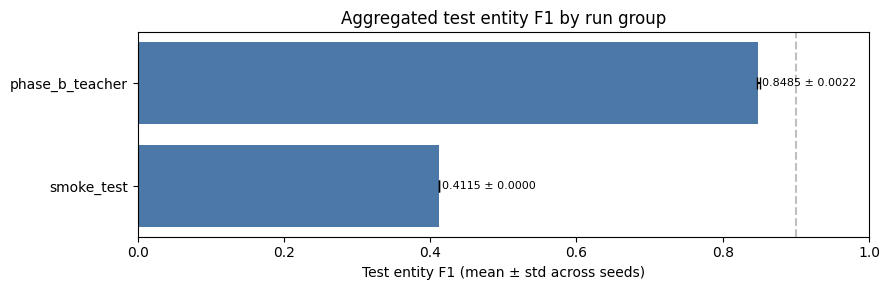

In [10]:
means = df.groupby('run_group')['test_entity_f1'].mean()
stds = df.groupby('run_group')['test_entity_f1'].std().fillna(0)
order = means.sort_values().index
fig, ax = plt.subplots(figsize=(9, max(3, 0.6 * len(order) + 1)))
y = np.arange(len(order))
ax.barh(y, means.loc[order], xerr=stds.loc[order], color='#4C78A8', capsize=4)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_xlabel('Test entity F1 (mean ± std across seeds)')
ax.set_xlim(0, 1)
ax.axvline(0.9, linestyle='--', color='gray', alpha=0.5)
ax.set_title('Aggregated test entity F1 by run group')
for i, g in enumerate(order):
    ax.text(means.loc[g] + 0.005, i, f'{means.loc[g]:.4f} ± {stds.loc[g]:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Raw comparison table

In [11]:
display_cols = ['run_id', 'model', 'seed', 'num_epochs', 'param_count', 'train_time_min',
                'best_val_entity_f1', 'val_entity_f1', 'test_entity_f1',
                'test_per_f1', 'test_loc_f1', 'test_org_f1']
df[display_cols].style.format({
    'best_val_entity_f1': '{:.4f}',
    'val_entity_f1': '{:.4f}',
    'test_entity_f1': '{:.4f}',
    'test_per_f1': '{:.4f}',
    'test_loc_f1': '{:.4f}',
    'test_org_f1': '{:.4f}',
    'train_time_min': '{:.2f}',
    'param_count': '{:,.0f}',
}, na_rep='-')

,run_id,model,seed,num_epochs,param_count,train_time_min,best_val_entity_f1,val_entity_f1,test_entity_f1,test_per_f1,test_loc_f1,test_org_f1
0,phase_b_teacher_seed5768,roberta-large,5768,30,"354,317,319",47.72,0.9178,0.9178,0.8510,0.9562,0.8444,0.8021
1,phase_b_teacher_seed78516,roberta-large,78516,30,"354,317,319",33.87,0.9129,0.9129,0.8475,0.9561,0.8544,0.7903
2,phase_b_teacher_seed88,roberta-large,88,30,"354,317,319",40.89,0.9148,0.9148,0.8468,0.9431,0.8627,0.7937
3,smoke_test_seed88,distilbert-base-cased,88,1,"65,196,295",0.54,0.4071,0.4071,0.4115,0.2252,0.4588,0.4614
